In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Import libraries

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
# Import RandomForestClassifier instead of LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

In [3]:
# ---------- 1️⃣ Load Chi² dataset ----------
chi2_df = pd.read_csv("/content/drive/MyDrive/SLIIT/AI_ML/Project/chi2_pca_df.csv")
X_chi2 = chi2_df.drop("Depression", axis=1)
y_chi2 = chi2_df["Depression"]

In [4]:
# ---------- 2️⃣ Load RFE dataset ----------
rfe_df = pd.read_csv("/content/drive/MyDrive/SLIIT/AI_ML/Project/rfe_pca_df.csv")
X_rfe = rfe_df.drop("Depression", axis=1)
y_rfe = rfe_df["Depression"]

In [5]:
# ---------- 3️⃣ Train-test split ----------
Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_chi2, y_chi2, test_size=0.2, random_state=42, stratify=y_chi2)
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_rfe, y_rfe, test_size=0.2, random_state=42, stratify=y_rfe)

In [6]:
# ---------- 4️⃣ Random Forest (same parameters for fair comparison) ----------
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

# Train and evaluate on Chi² dataset
rf.fit(Xc_train, yc_train)
yc_pred = rf.predict(Xc_test)
acc_chi2 = accuracy_score(yc_test, yc_pred)

# Train and evaluate on RFE dataset
rf.fit(Xr_train, yr_train)
yr_pred = rf.predict(Xr_test)
acc_rfe = accuracy_score(yr_test, yr_pred)

In [7]:
# ---------- 5️⃣ Evaluate and Compare ----------
from sklearn.metrics import classification_report, confusion_matrix

print(f"📊 Chi² Dataset Accuracy: {acc_chi2:.4f}")
print(f"📊 RFE Dataset Accuracy: {acc_rfe:.4f}")

print("\n🔍 RFE Classification Report:\n", classification_report(yr_test, yr_pred))
print("\n🔍 Chi² Classification Report:\n", classification_report(yc_test, yc_pred))

print("\nConfusion Matrix (RFE):\n", confusion_matrix(yr_test, yr_pred))
print("\nConfusion Matrix (Chi²):\n", confusion_matrix(yc_test, yc_pred))

📊 Chi² Dataset Accuracy: 0.8450
📊 RFE Dataset Accuracy: 0.8481

🔍 RFE Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.79      0.81      2311
           1       0.86      0.89      0.87      3264

    accuracy                           0.85      5575
   macro avg       0.85      0.84      0.84      5575
weighted avg       0.85      0.85      0.85      5575


🔍 Chi² Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.79      0.81      2311
           1       0.85      0.89      0.87      3264

    accuracy                           0.85      5575
   macro avg       0.84      0.84      0.84      5575
weighted avg       0.84      0.85      0.84      5575


Confusion Matrix (RFE):
 [[1834  477]
 [ 370 2894]]

Confusion Matrix (Chi²):
 [[1815  496]
 [ 368 2896]]


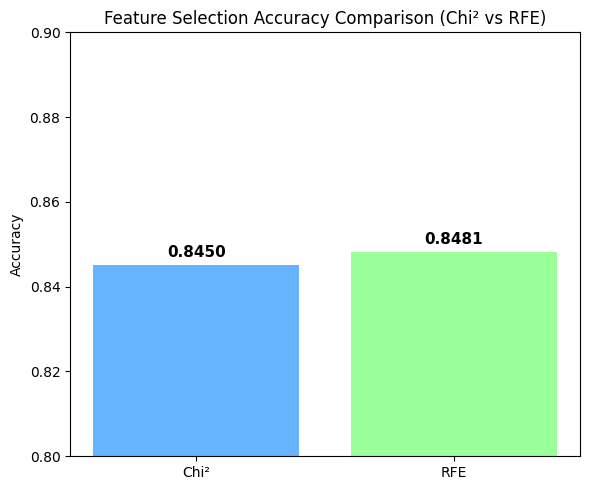

In [8]:
# ---------- 6️⃣ Visual Comparison (Bar Chart) ----------
plt.figure(figsize=(6,5))
plt.bar(['Chi²', 'RFE'], [acc_chi2, acc_rfe], color=['#66b3ff', '#99ff99'])
plt.ylim(0.8, 0.9)
plt.ylabel('Accuracy')
plt.title('Feature Selection Accuracy Comparison (Chi² vs RFE)')

# Add text labels above bars
for i, acc in enumerate([acc_chi2, acc_rfe]):
    plt.text(i, acc + 0.002, f"{acc:.4f}", ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


In [9]:
# ===========================================
# ⚙️ Step 7: Manual Hyperparameter Tuning (RFE Dataset)
# ===========================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

# Load RFE dataset again (optional if already in memory)
rfe_df = pd.read_csv("/content/drive/MyDrive/SLIIT/AI_ML/Project/rfe_pca_df.csv")
X = rfe_df.drop("Depression", axis=1)
y = rfe_df["Depression"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Parameter ranges to test manually
n_estimators_list = [100, 300, 500, 800]
max_depth_list = [10, 20, 30, None]
min_samples_split_list = [2, 5, 10]
min_samples_leaf_list = [1, 2, 4]
max_features_list = ['sqrt', 'log2']

# Store results
results = []

# Loop through all combinations
for n in n_estimators_list:
    for d in max_depth_list:
        for split in min_samples_split_list:
            for leaf in min_samples_leaf_list:
                for mf in max_features_list:
                    model = RandomForestClassifier(
                        n_estimators=n,
                        max_depth=d,
                        min_samples_split=split,
                        min_samples_leaf=leaf,
                        max_features=mf,
                        random_state=42,
                        n_jobs=-1
                    )
                    model.fit(X_train, y_train)
                    y_pred = model.predict(X_test)
                    acc = accuracy_score(y_test, y_pred)
                    results.append({
                        'n_estimators': n,
                        'max_depth': d,
                        'min_samples_split': split,
                        'min_samples_leaf': leaf,
                        'max_features': mf,
                        'accuracy': acc
                    })
                    print(f"Trained n={n}, depth={d}, split={split}, leaf={leaf}, features={mf} → Acc={acc:.4f}")

# Convert to DataFrame
results_df = pd.DataFrame(results)

print("\n===== 🔍 Top 10 Results =====")
print(results_df.sort_values(by='accuracy', ascending=False).head(10))


Trained n=100, depth=10, split=2, leaf=1, features=sqrt → Acc=0.8456
Trained n=100, depth=10, split=2, leaf=1, features=log2 → Acc=0.8456
Trained n=100, depth=10, split=2, leaf=2, features=sqrt → Acc=0.8439
Trained n=100, depth=10, split=2, leaf=2, features=log2 → Acc=0.8447
Trained n=100, depth=10, split=2, leaf=4, features=sqrt → Acc=0.8474
Trained n=100, depth=10, split=2, leaf=4, features=log2 → Acc=0.8463
Trained n=100, depth=10, split=5, leaf=1, features=sqrt → Acc=0.8434
Trained n=100, depth=10, split=5, leaf=1, features=log2 → Acc=0.8454
Trained n=100, depth=10, split=5, leaf=2, features=sqrt → Acc=0.8452
Trained n=100, depth=10, split=5, leaf=2, features=log2 → Acc=0.8439
Trained n=100, depth=10, split=5, leaf=4, features=sqrt → Acc=0.8474
Trained n=100, depth=10, split=5, leaf=4, features=log2 → Acc=0.8463
Trained n=100, depth=10, split=10, leaf=1, features=sqrt → Acc=0.8475
Trained n=100, depth=10, split=10, leaf=1, features=log2 → Acc=0.8461
Trained n=100, depth=10, split=1


🔥 Best Parameters Found:
n_estimators              300
max_depth                10.0
min_samples_split           2
min_samples_leaf            2
max_features             sqrt
accuracy             0.848072
Name: 74, dtype: object

✅ Final model retrained successfully!

📊 Final Model Accuracy: 0.8481

Confusion Matrix:
 [[1834  477]
 [ 370 2894]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.79      0.81      2311
           1       0.86      0.89      0.87      3264

    accuracy                           0.85      5575
   macro avg       0.85      0.84      0.84      5575
weighted avg       0.85      0.85      0.85      5575



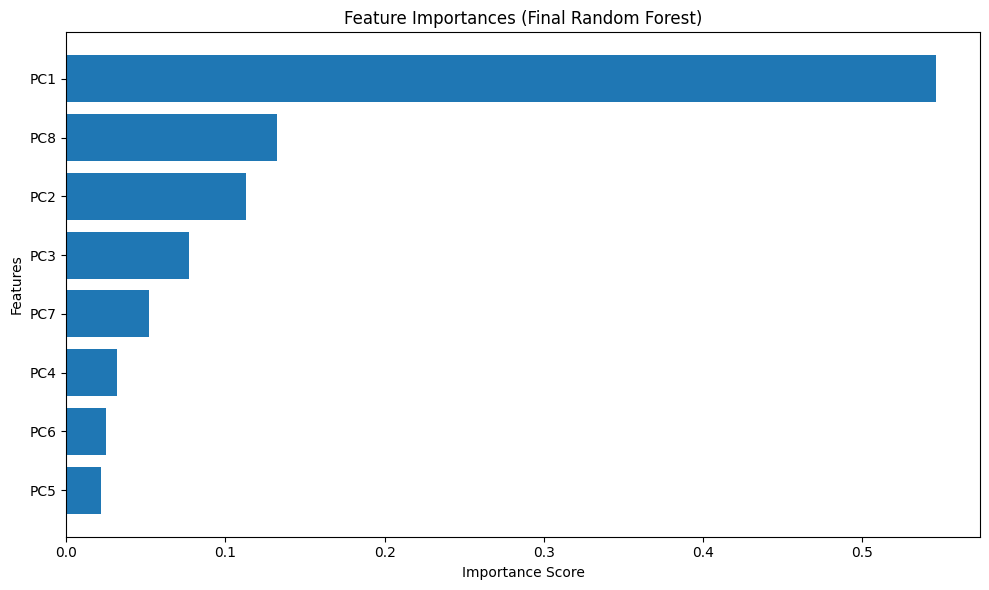


💾 Final model saved as 'final_random_forest_model.pkl'


In [10]:
# ===========================================
# 🎯 Step 8: Train Final Model with Best Parameters
# ===========================================

from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import joblib

# 1️⃣ Get the best-performing parameter set
best_row = results_df.loc[results_df['accuracy'].idxmax()]
print("\n🔥 Best Parameters Found:")
print(best_row)

# 2️⃣ Retrain the model using the best parameters
best_model = RandomForestClassifier(
    n_estimators=int(best_row['n_estimators']),
    max_depth=None if pd.isna(best_row['max_depth']) else int(best_row['max_depth']),
    min_samples_split=int(best_row['min_samples_split']),
    min_samples_leaf=int(best_row['min_samples_leaf']),
    max_features=best_row['max_features'],
    random_state=42,
    n_jobs=-1
)
best_model.fit(X_train, y_train)
print("\n✅ Final model retrained successfully!")

# 3️⃣ Evaluate on test data
y_pred = best_model.predict(X_test)
final_acc = accuracy_score(y_test, y_pred)
print(f"\n📊 Final Model Accuracy: {final_acc:.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 4️⃣ Feature importance visualization
importances = best_model.feature_importances_
features = X.columns
sorted_idx = importances.argsort()

plt.figure(figsize=(10, 6))
plt.barh(features[sorted_idx], importances[sorted_idx])
plt.title("Feature Importances (Final Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

# 5️⃣ Save the model for future use
joblib.dump(best_model, "/content/drive/MyDrive/SLIIT/AI_ML/Project/final_random_forest_model.pkl")
print("\n💾 Final model saved as 'final_random_forest_model.pkl'")


In [11]:
y_pred = best_model.predict(X_test)


Confusion Matrix:
 [[1834  477]
 [ 370 2894]]


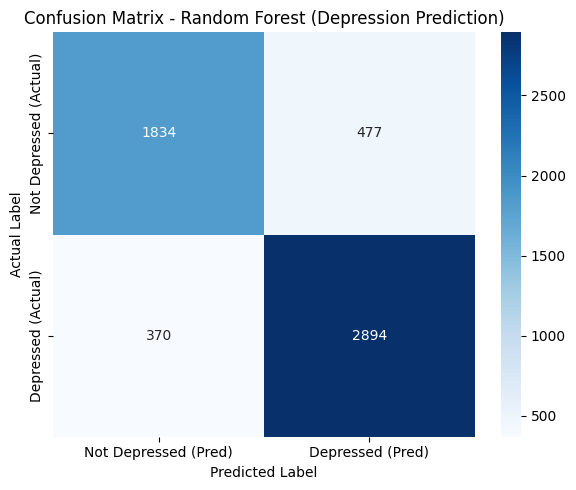

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display numerical matrix
print("Confusion Matrix:\n", cm)

# Create labeled heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Depressed (Pred)', 'Depressed (Pred)'],
            yticklabels=['Not Depressed (Actual)', 'Depressed (Actual)'])
plt.title('Confusion Matrix - Random Forest (Depression Prediction)')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()


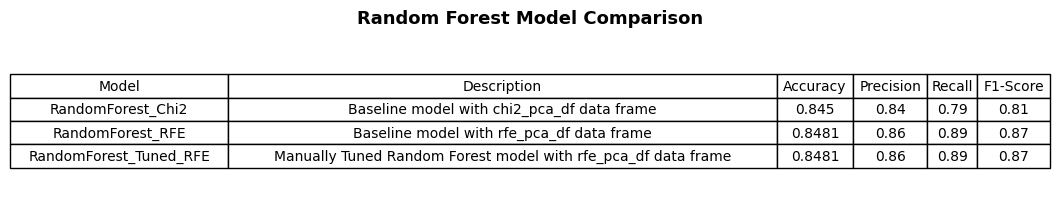

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Create DataFrame for Random Forest model comparison
rf_results = pd.DataFrame({
    "Model": [
        "RandomForest_Chi2",
        "RandomForest_RFE",
        "RandomForest_Tuned_RFE"
    ],
    "Description": [
        "Baseline model with chi2_pca_df data frame",
        "Baseline model with rfe_pca_df data frame",
        "Manually Tuned Random Forest model with rfe_pca_df data frame"
    ],
    "Accuracy": [0.8450, 0.8481, 0.8481],
    "Precision": [0.84, 0.86, 0.86],
    "Recall": [0.79, 0.89, 0.89],
    "F1-Score": [0.81, 0.87, 0.87]
})

# Display table
fig, ax = plt.subplots(figsize=(9, 2))
ax.axis('off')
table = ax.table(
    cellText=rf_results.values,
    colLabels=rf_results.columns,
    loc='center',
    cellLoc='center'
)

# Style adjustments
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.4)
table.auto_set_column_width(col=list(range(len(rf_results.columns))))
plt.title("Random Forest Model Comparison", fontsize=13, fontweight='bold', pad=15)
plt.show()


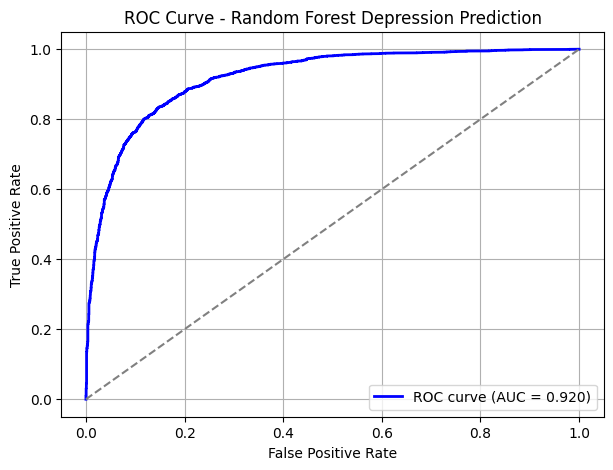

In [15]:
from sklearn.metrics import roc_curve, auc

y_pred_proba = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest Depression Prediction")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


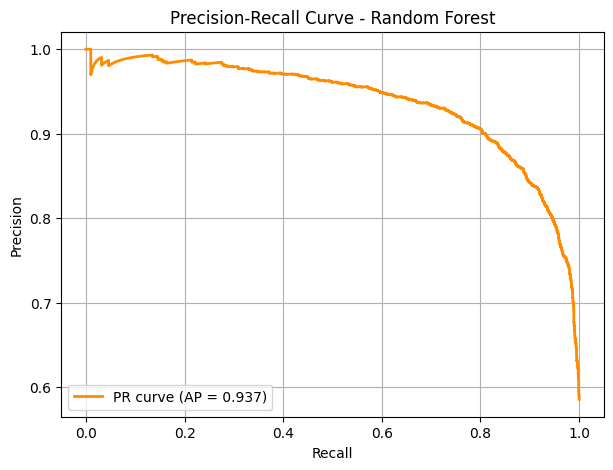

In [16]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
ap_score = average_precision_score(y_test, y_pred_proba)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, color='darkorange', lw=2,
         label=f'PR curve (AP = {ap_score:.3f})')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Random Forest")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()
